This Juptyer Notebook is meant to use SQL queries in order to aggregate the csv data for preliminary data analysis. We will create features like heat, elevation, vegetation, while also retaining key information about each fire, including time, duration, and location. We will then conduct some basic EDA to observe the effect of various predictors on fire size. 


In [8]:
%pip install duckdb pandas matplotlib seaborn scikit-learn

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 294 kB 96 kB/s eta 0:00:01
     |████████████████████████████████| 11.1 MB 264 kB/s eta 0:00:01
     |████████████████████████████████| 309 kB 151 kB/s eta 0:00:01
     |████████████████████████████████| 30.3 MB 536 kB/s eta 0:00:01
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


Import the necessary packages. 

In [9]:
import duckdb 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
con = duckdb.connect()

In [11]:
con.execute("""
CREATE TABLE wildfires AS
SELECT * FROM read_csv_auto('all_fires_full.csv')
""")

In [13]:
con.execute("SELECT * FROM wildfires LIMIT 5").df() #preliminary checking of the data

,fire_id,date,days_to_ignition,phase,bi,erc,fm100,fm1000,tmmx,tmmn,...,nlcd_forest_ever,nlcd_forest_mixed,nlcd_shrub,nlcd_grassland,nlcd_pasture,nlcd_crops,nlcd_wetland_woody,nlcd_wetland_herb,tmmx_c,tmmn_c
0,10TH_2024_00139,2023-06-25,-365,pre_fire,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.992593,0.0,0.0,0.0,0.0,0.0,NaN,NaN
1,10TH_2024_00139,2023-06-26,-364,pre_fire,93.666664,83.666664,5.233334,7.183334,301.60000,289.84998,...,0.0,0.0,0.992593,0.0,0.0,0.0,0.0,0.0,28.45000,16.69998
2,10TH_2024_00139,2023-06-27,-363,pre_fire,89.500000,84.000000,5.350000,7.100000,305.19998,291.13333,...,0.0,0.0,0.992593,0.0,0.0,0.0,0.0,0.0,32.04998,17.98333
3,10TH_2024_00139,2023-06-28,-362,pre_fire,85.833336,84.333336,5.400000,6.983334,304.85000,291.20000,...,0.0,0.0,0.992593,0.0,0.0,0.0,0.0,0.0,31.70000,18.05000
4,10TH_2024_00139,2023-06-29,-361,pre_fire,62.166668,86.333336,5.250000,6.883334,309.86667,291.40000,...,0.0,0.0,0.992593,0.0,0.0,0.0,0.0,0.0,36.71667,18.25000


Inspecting the data structure 

In [14]:
con.execute("DESCRIBE wildfires").df() #checking the columns and their data types

,column_name,column_type,null,key,default,extra
0,fire_id,VARCHAR,YES,None,None,None
1,date,DATE,YES,None,None,None
2,days_to_ignition,BIGINT,YES,None,None,None
3,phase,VARCHAR,YES,None,None,None
4,bi,DOUBLE,YES,None,None,None
5,erc,DOUBLE,YES,None,None,None
6,fm100,DOUBLE,YES,None,None,None
7,fm1000,DOUBLE,YES,None,None,None
8,tmmx,DOUBLE,YES,None,None,None
9,tmmn,DOUBLE,YES,None,None,None


There are 44 columns in this CSV. 

In [15]:
con.execute("SELECT COUNT(*) FROM wildfires").fetchall() #checking number of rows in the data

[(2872673,)]

Here, we see that the shape of the data is 2872673, indicating that there are over 2 million entries. 

In [16]:
con.execute("""
SELECT COUNT(DISTINCT fire_id)
FROM wildfires
""").fetchall() #checking number of unique fire incidents in the data, since there are multiple rows for each fire incident (one for each day the fire was active)

[(7662,)]

In [17]:
con.execute("""
SELECT fire_id, COUNT(*) as days_recorded
FROM wildfires
GROUP BY fire_id
ORDER BY days_recorded DESC
LIMIT 10
""").df() #this checks the number of days recorded for each fire incident, to see if there are any incidents that were active for a long time and thus have many rows in the data. This can help us understand the distribution of the data and identify any potential outliers.

,fire_id,days_recorded
0,SOUTHERN_2021_01122,735
1,WESTLAKE_2006_06249,732
2,GORGE_2018_02409,731
3,TIVY_2021_01299,731
4,PANTHER_2013_03949,588
5,POWERHOUSE_2013_03937,568
6,LAKE_2015_03486,563
7,ROSASCO_2019_02026,559
8,PONY_2016_03192,557
9,TENNANT_2021_01118,555


Here, we want to create a temperatures feature, where we can calculate the average temperature over the last six months by specific fire ID. 

In [ ]:
temperature_features = con.execute("""
SELECT
    fire_id,

    AVG(tmmx_c) AS avg_max_temp_6mo,
    AVG(tmmn_c) AS avg_min_temp_6mo,

    MAX(tmmx_c) AS hottest_day_6mo,
    MIN(tmmn_c) AS coldest_day_6mo,

    AVG(tmmx_c - tmmn_c) AS avg_daily_temp_range

FROM wildfires
WHERE days_to_ignition BETWEEN -180 AND -1 -- considering the 6 months leading up to ignition
GROUP BY fire_id
""").df()

temperature_features.head()

,fire_id,avg_max_temp_6mo,avg_min_temp_6mo,hottest_day_6mo,coldest_day_6mo,avg_daily_temp_range
0,AUGUST_COMPLEX_2020_01489,22.826614,8.814267,37.29186,-2.18366,14.012348
1,AVENIDA_2007_05908,20.045308,5.630557,34.61670,-6.33884,14.414751
2,AVOCADO_2016_03260,18.756019,6.588427,36.50002,-1.55000,12.167592
3,BABCOCK_2007_05785,10.211112,-2.476421,24.87222,-23.83889,12.687533
4,BACKBONE_2009_05116,24.410092,10.142223,41.91665,-2.13334,14.267869


In [22]:
heat_features = con.execute("""
SELECT
    fire_id,
    COUNT(*) AS hot_days_6mo
FROM wildfires
WHERE
    days_to_ignition BETWEEN -180 AND -1
    AND tmmx_c > 35
GROUP BY fire_id
""").df()

heat_features.head()
#calculates the extreme heat days from over the past 6 months. 

,fire_id,hot_days_6mo
0,ELK_2005_06402,20
1,ELK_2023_00757,4
2,ELLIOT_2020_01658,2
3,ESTATE_2017_02897,60
4,EVANS_2008_05484,12


In [24]:
elevation_features = con.execute("""
SELECT
    fire_id,

    MAX(elev_mean) AS mean_elevation,
    MAX(elev_std) AS elevation_variability,
    MAX(slope_mean) AS mean_slope

FROM wildfires
GROUP BY fire_id
""").df()

elevation_features.head()

#this calculates the mean elevation, elevation variability, and mean slope for each fire incident, which can help us understand the terrain characteristics of the areas where fires occur.

,fire_id,mean_elevation,elevation_variability,mean_slope
0,ELK_2008_05397,350.790974,65.613344,7.596633
1,ELMORE_2008_05424,NaN,NaN,NaN
2,ELM_2005_06408,766.089604,213.412233,13.726685
3,ELSMERE_2020_01635,465.783011,29.078082,5.797657
4,EMPIRE_2022_01071,NaN,NaN,NaN


In [29]:
vegetation_raw = con.execute("""
SELECT
    fire_id,

    MAX(nlcd_open_water) AS open_water,
    MAX(nlcd_dev_open) AS dev_open,
    MAX(nlcd_dev_low) AS dev_low,
    MAX(nlcd_dev_med) AS dev_med,
    MAX(nlcd_dev_high) AS dev_high,

    MAX(nlcd_barren) AS barren,

    MAX(nlcd_forest_decid) AS forest_decid,
    MAX(nlcd_forest_ever) AS forest_ever,
    MAX(nlcd_forest_mixed) AS forest_mixed,

    MAX(nlcd_shrub) AS shrub,
    MAX(nlcd_grassland) AS grassland,

    MAX(nlcd_pasture) AS pasture,
    MAX(nlcd_crops) AS crops,

    MAX(nlcd_wetland_woody) AS wetland, 
    MAX(nlcd_wetland_herb) AS wetland_herb

FROM wildfires
GROUP BY fire_id
""").df()

In [30]:
veg = vegetation_raw.copy()

veg["forest_fraction"] = (
    veg["forest_decid"] +
    veg["forest_ever"] +
    veg["forest_mixed"]
)

veg["shrub_fraction"] = veg["shrub"]

veg["grass_fraction"] = veg["grassland"]

veg["developed_fraction"] = (
    veg["dev_open"] +
    veg["dev_low"] +
    veg["dev_med"] +
    veg["dev_high"]
)

veg["agriculture_fraction"] = (
    veg["pasture"] +
    veg["crops"]
)

veg["nonburnable_fraction"] = (
    veg["open_water"] +
    veg["barren"] +
    veg["wetland"]
)

In [44]:
veg["dominant_veg"] = veg[
    ["forest_fraction","shrub_fraction","grass_fraction"]
].idxmax(axis=1)

In [45]:
fire_metadata = con.execute("""
SELECT
    fire_id,

    MAX(gis_acres) AS fire_size,

    MIN(date) AS ignition_date,
    MAX(date) AS containment_date,

    DATE_DIFF('day', MIN(date), MAX(date)) AS duration_days,

    MAX(lat_centroid) AS latitude,
    MAX(lon_centroid) AS longitude,

    EXTRACT(YEAR FROM MIN(date)) AS ignition_year,
    EXTRACT(MONTH FROM MIN(date)) AS ignition_month

FROM wildfires
GROUP BY fire_id
ORDER BY fire_id 
""").df()

In [52]:
data = (
    fire_metadata
    .merge(heat_features, on="fire_id", how="left")
    .merge(temperature_features, on="fire_id", how="left")
    .merge(elevation_features, on="fire_id", how="left")
    .merge(veg, on="fire_id", how="left")
)

data.head()

,fire_id,fire_size,ignition_date,containment_date,duration_days,latitude,longitude,ignition_year,ignition_month,hot_days_6mo,...,crops,wetland,wetland_herb,forest_fraction,shrub_fraction,grass_fraction,developed_fraction,agriculture_fraction,nonburnable_fraction,dominant_veg
0,10TH_2024_00139,131.961304,2023-06-25,2024-06-25,366,34.971166,-118.109886,2023,6,12.0,...,0.000000,0.000000,0.0,0.000000,0.992593,0.000000,0.007407,0.000000,0.000000,shrub_fraction
1,10_2003_07027,212.883774,2002-09-03,2003-09-10,372,40.132079,-124.084808,2002,9,NaN,...,0.000000,0.003401,0.0,0.382653,0.044785,0.569161,0.000000,0.000000,0.003401,grass_fraction
2,118_FWY_2015_03742,4.027377,2014-06-04,2015-06-04,365,34.275892,-118.625533,2014,6,NaN,...,0.000000,0.000000,0.0,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,shrub_fraction
3,128_2002_07316,187.959915,2001-09-04,2002-09-05,366,38.507163,-122.091515,2001,9,29.0,...,0.000000,0.000000,0.0,0.000000,0.950000,0.002083,0.007639,0.000000,0.040278,shrub_fraction
4,128_2006_06210,57.198334,2005-07-07,2006-07-07,365,38.438790,-122.169162,2005,7,7.0,...,0.079365,0.835317,0.0,0.000000,0.047619,0.000000,0.000000,0.117063,0.835317,shrub_fraction


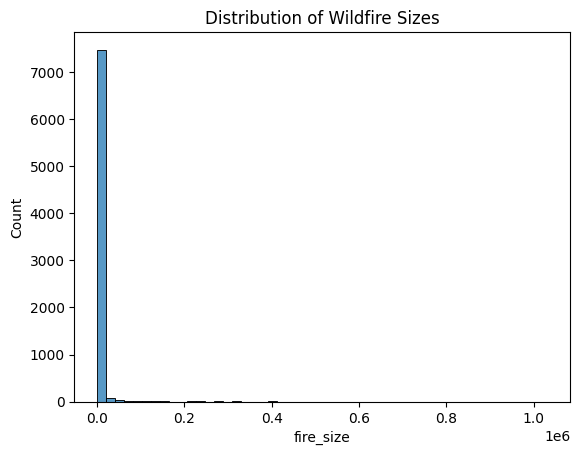

In [54]:
sns.histplot(data["fire_size"], bins=50)
plt.title("Distribution of Wildfire Sizes")
plt.show()

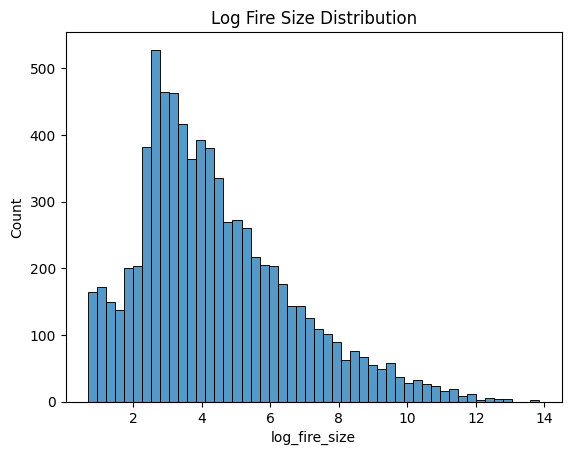

In [55]:
import numpy as np

data["log_fire_size"] = np.log1p(data["fire_size"])

sns.histplot(data["log_fire_size"], bins=50)
plt.title("Log Fire Size Distribution")
plt.show()

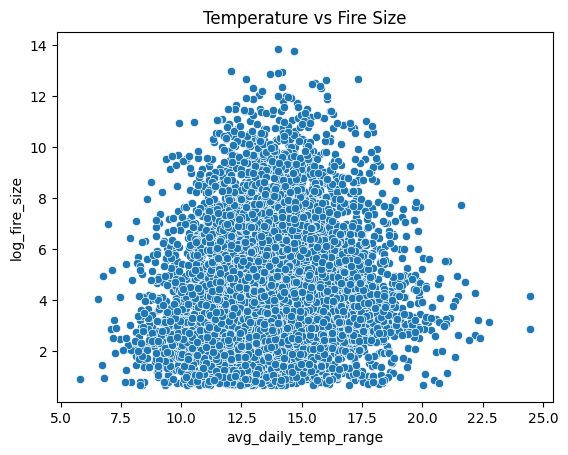

In [56]:
sns.scatterplot(x="avg_daily_temp_range", y="log_fire_size", data=data)
plt.title("Temperature vs Fire Size")
plt.show()

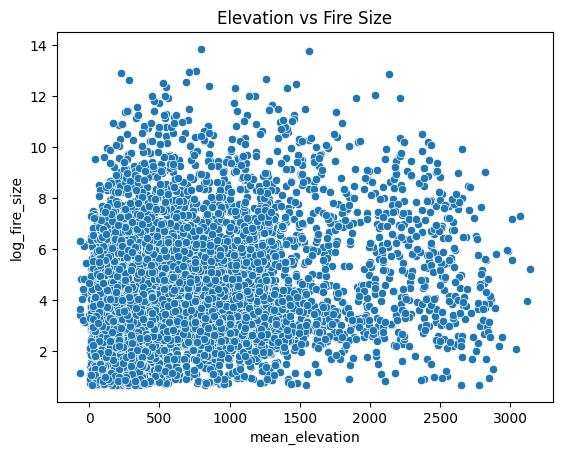

In [57]:
sns.scatterplot(x="mean_elevation", y="log_fire_size", data=data)
plt.title("Elevation vs Fire Size")
plt.show()

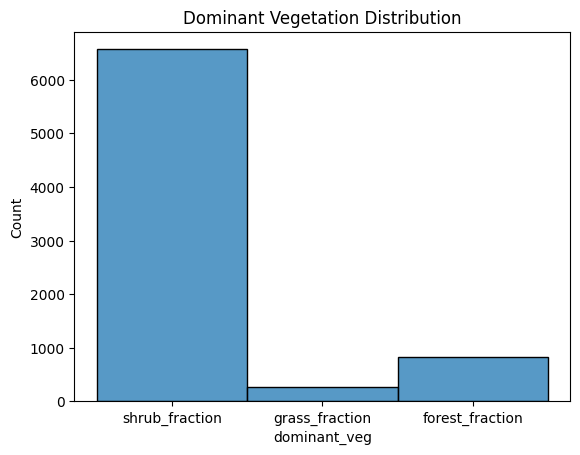

In [58]:
import numpy as np


sns.histplot(data["dominant_veg"], bins=50)
plt.title("Dominant Vegetation Distribution")
plt.show()